# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Name:** Gimhan <br>
**Index No:** 230018T <br>
**GitHub:** https://github.com/Gimadikaram/EN3160-Image-Processing-Assignment-1




In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
IMG_DIR = "C:/Users/ASUS/Downloads/EN3160-Image-Processing-Assignment-1/inputs images/"


## Question 1 — Piecewise-linear intensity transformation



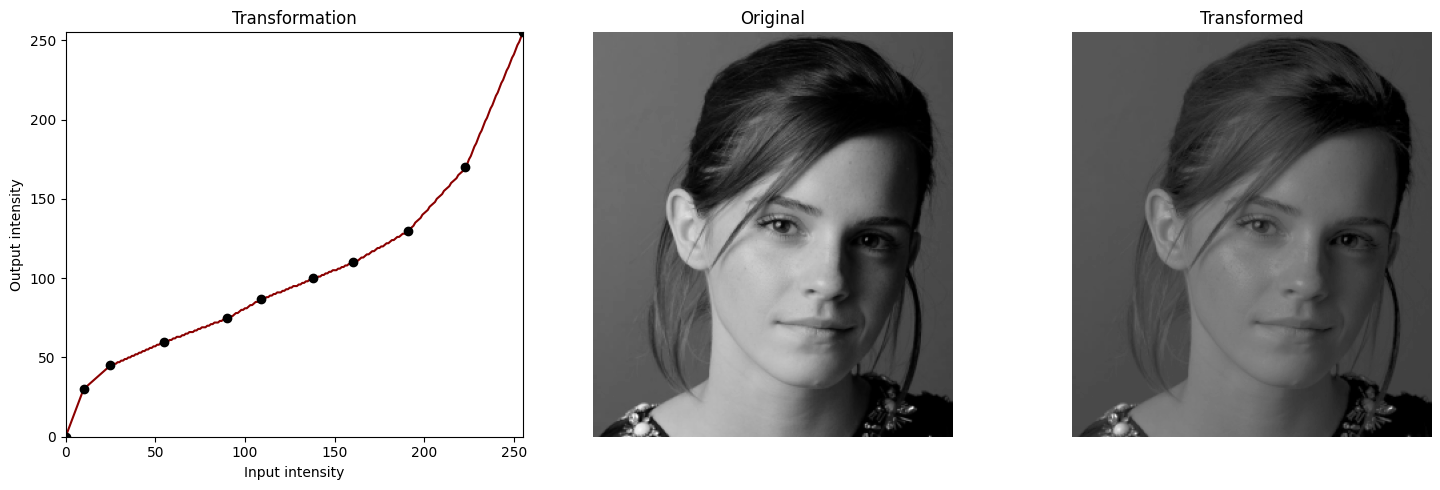

In [6]:
def intensity_transform(im, breakpoints):
   
    bp = np.array(breakpoints, dtype=np.float64)
    xs, ys = bp[:, 0], bp[:, 1]
    x_full = np.arange(256)
    lut = np.clip(np.interp(x_full, xs, ys), 0, 255).astype(np.uint8)
    out = cv2.LUT(im, lut)
    return out, lut



img1 = cv2.imread(IMG_DIR + "q1.png", cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [10,30],
    [25, 45],
    [55, 60],
    [90, 75],
    [109, 87],
    [138, 100],
    [160, 110],
    [191, 130],
    [223, 170],
    [255, 255]
]

transformed1, lut1 = intensity_transform(img1, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut1, color='darkred')
axes[0].scatter(*zip(*breakpoints), color='black', zorder=3)
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity"); axes[0].set_ylabel("Output intensity")
axes[0].set_title("Transformation")

axes[1].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original"); axes[1].axis('off')

axes[2].imshow(transformed1, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed"); axes[2].axis('off')

plt.tight_layout()
plt.show()




<h3>Discussion-</h3>
<b>Shadow Recovery:</b> A steep slope in the lower intensity range (e.g., mapping 25 to 45) lifts dark tones to reveal detail in the shadowed right side of the face.

<b>Highlight Compression:</b> A reduced slope across mid-to-high intensities (e.g., mapping 191 to 130) tones down overexposure on the left cheek and restores local contrast.

<b>Gradient Preservation:</b> Dense, closely spaced breakpoints ensure smooth piecewise linear interpolation, preserving natural luminance transitions in the hair and forehead without posterization while retaining the 255 white point.